In [ ]:
import torch

import numpy as np
from torchvision.utils import save_image
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Define VAE
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 2 * latent_dim)  # mu and log_var
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = h[:, :self.latent_dim], h[:, self.latent_dim:]
        z = self.reparameterize(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x.view(-1, 1, 28, 28), mu, log_var

# Loss function
def loss_function(recon_x, x, mu, log_var):
    bce_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return bce_loss + kld, bce_loss, kld

# Data loaders
transform = transforms.ToTensor()
trainloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)
testloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=128, shuffle=False
)




In [ ]:
# PART 1: Train and visualize for latent dimension = 2
def part1():
    latent_dim = 2
    model = VAE(latent_dim)
    if torch.cuda.is_available():
        model.cuda()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, "max", factor=0.5, patience=5, threshold=0.001, cooldown=0, min_lr=0.0001
    )

    for epoch in range(1, 11):  # 10 epochs
        model.train()
        train_loss = 0
        for batch_idx, (data, _) in enumerate(trainloader):
            data = data.cuda()
            recon_batch, mu, std = model(data)
            loss, err, kld = loss_function(recon_batch, data, mu, std)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step(train_loss / len(trainloader.dataset))
        print(f"Latent Dim {latent_dim}, Epoch {epoch}, Train Loss: {train_loss / len(trainloader.dataset):.4f}")


part1()


Latent Dim 2, Epoch 1, Train Loss: 181.8442
Latent Dim 2, Epoch 2, Train Loss: 163.8975
Latent Dim 2, Epoch 3, Train Loss: 160.0738
Latent Dim 2, Epoch 4, Train Loss: 158.0292
Latent Dim 2, Epoch 5, Train Loss: 156.5587
Latent Dim 2, Epoch 6, Train Loss: 155.4402
Latent Dim 2, Epoch 7, Train Loss: 154.6099
Latent Dim 2, Epoch 8, Train Loss: 152.8098
Latent Dim 2, Epoch 9, Train Loss: 152.3316
Latent Dim 2, Epoch 10, Train Loss: 151.9176



Visualization for Latent Dimension 2:


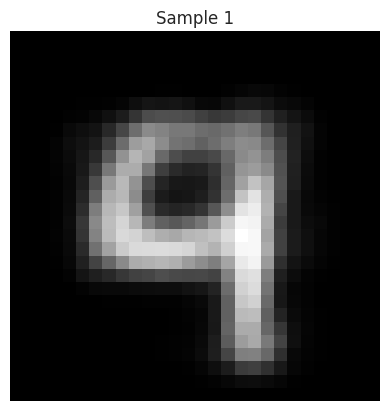

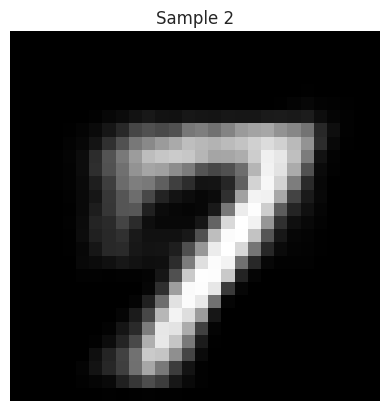

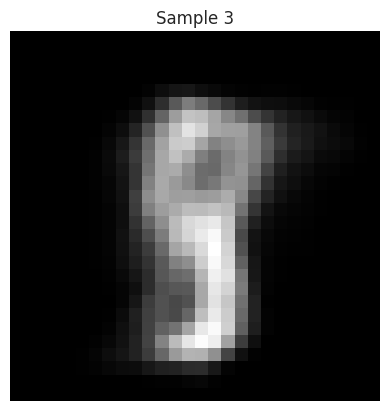

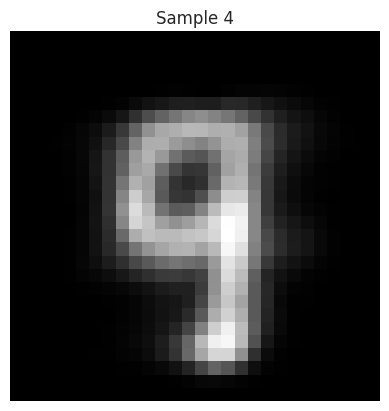

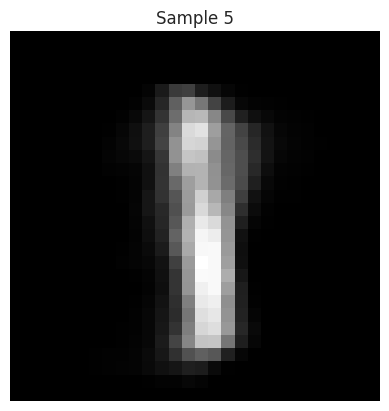

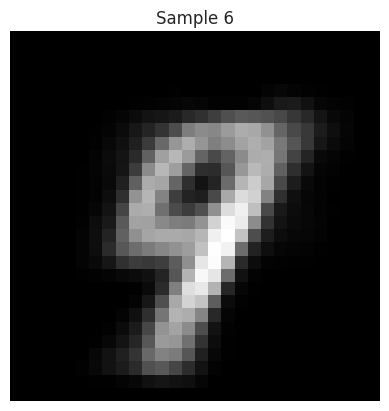

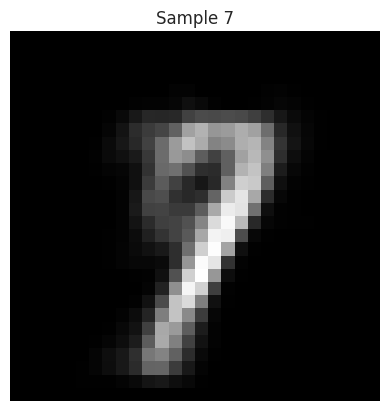

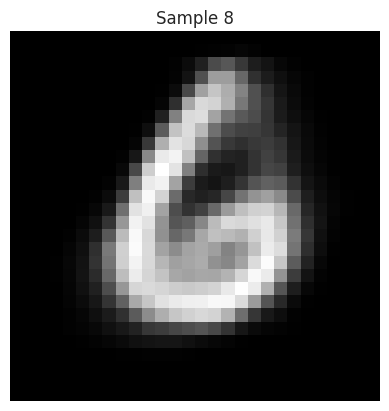

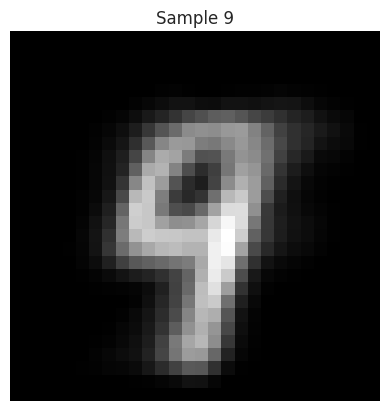

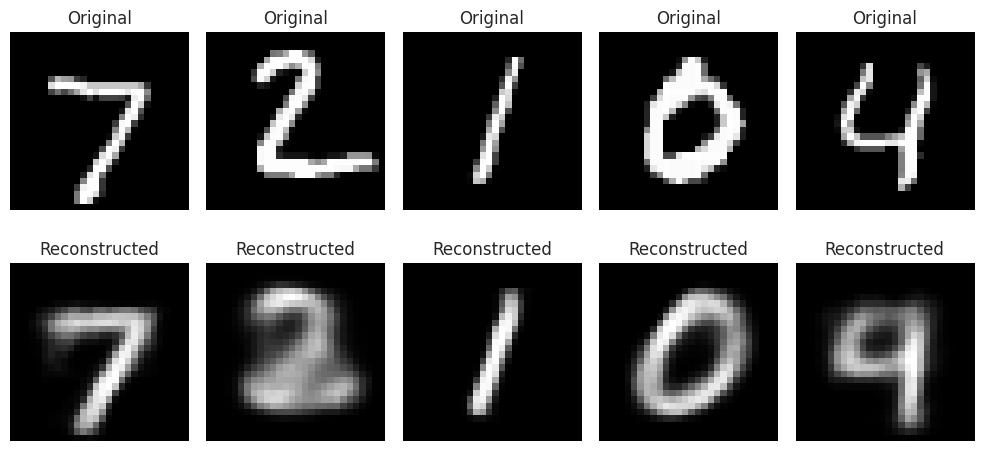

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# Set Seaborn style
sns.set(style="whitegrid")

# Visualization: Latent Vector Sampling
model.eval()
print(f"\nVisualization for Latent Dimension {latent_dim}:")
for i in range(9):
    # Sample a random latent vector from a normal distribution
    x = np.random.normal(0, 1, latent_dim).astype(np.float32)
    x = torch.from_numpy(x).cuda()

    # Perform the reconstruction from the latent space
    with torch.no_grad():
        recon = model.decoder(x)

    # Reshape and visualize the reconstructed image
    recon_image = recon.view(28, 28).cpu().numpy()
    plt.imshow(recon_image, cmap="gray")
    plt.title(f"Sample {i+1}")
    plt.axis('off')  # Hide axes for better visualization
    plt.show()

# Visualization: Reconstruction
data, _ = next(iter(testloader))
data = data.cuda()

# Perform the reconstruction for a batch of images
with torch.no_grad():
    recon_batch, _, _ = model(data)

# Plot the original and reconstructed images
plt.figure(figsize=(10, 5))  # Set figure size to accommodate both sets of images
for i in range(5):  # Visualize 5 pairs of original and reconstructed images
    # Original Image
    plt.subplot(2, 5, i + 1)
    plt.imshow(data[i].view(28, 28).cpu().numpy(), cmap="gray")
    plt.title("Original")
    plt.axis('off')  # Hide axes

    # Reconstructed Image
    plt.subplot(2, 5, i + 6)
    plt.imshow(recon_batch[i].view(28, 28).cpu().numpy(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis('off')  # Hide axes

plt.tight_layout()  # To avoid overlap in the plot
plt.show()


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Latent Dim 4, Epoch 1, Train Loss: 164.6966
Latent Dim 4, Epoch 2, Train Loss: 142.6305
Latent Dim 4, Epoch 3, Train Loss: 138.7372
Latent Dim 4, Epoch 4, Train Loss: 136.3998
Latent Dim 4, Epoch 5, Train Loss: 134.8324
Latent Dim 4, Epoch 6, Train Loss: 133.6518
Latent Dim 4, Epoch 7, Train Loss: 132.6884
Latent Dim 4, Epoch 8, Train Loss: 131.0580
Latent Dim 4, Epoch 9, Train Loss: 130.5876
Latent Dim 4, Epoch 10, Train Loss: 130.2519


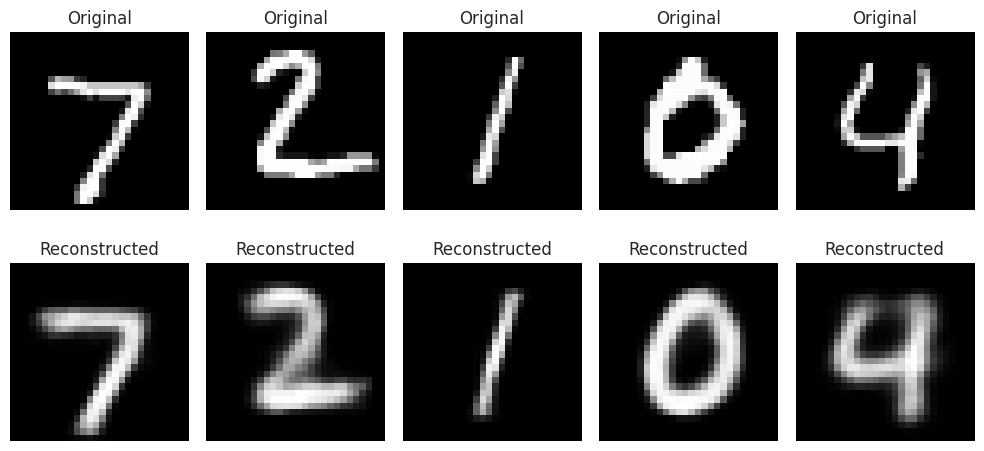

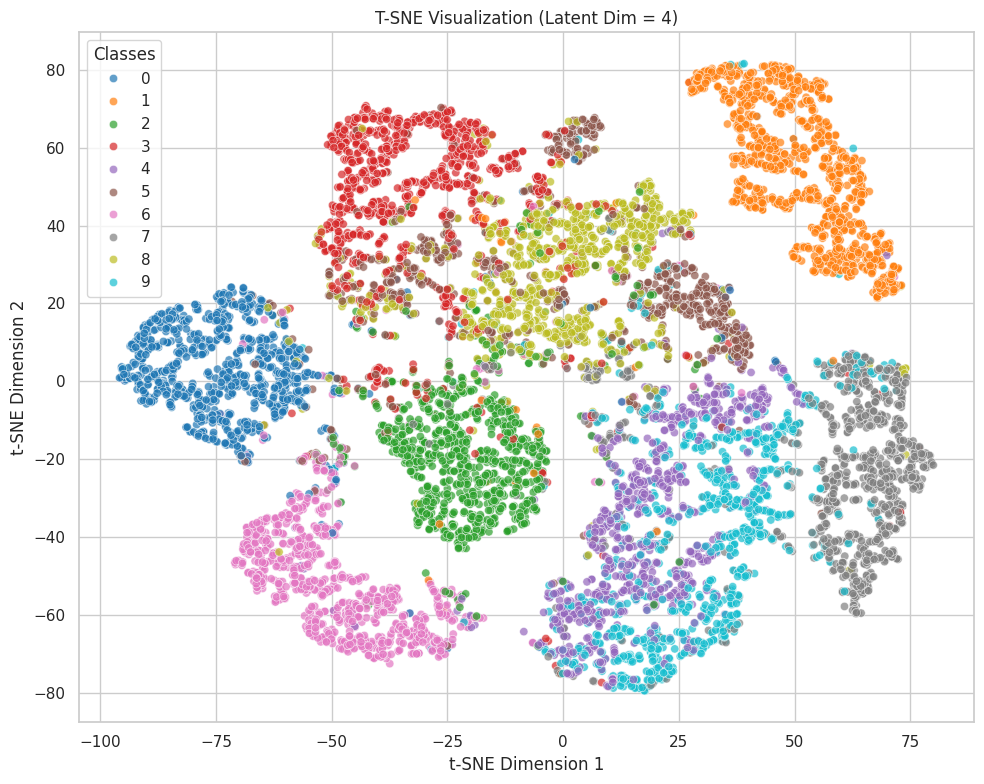

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Latent Dim 16, Epoch 1, Train Loss: 150.2075
Latent Dim 16, Epoch 2, Train Loss: 116.4650
Latent Dim 16, Epoch 3, Train Loss: 112.1391
Latent Dim 16, Epoch 4, Train Loss: 110.0752
Latent Dim 16, Epoch 5, Train Loss: 108.9610
Latent Dim 16, Epoch 6, Train Loss: 108.0595
Latent Dim 16, Epoch 7, Train Loss: 107.4342
Latent Dim 16, Epoch 8, Train Loss: 105.8735
Latent Dim 16, Epoch 9, Train Loss: 105.5840
Latent Dim 16, Epoch 10, Train Loss: 105.3618


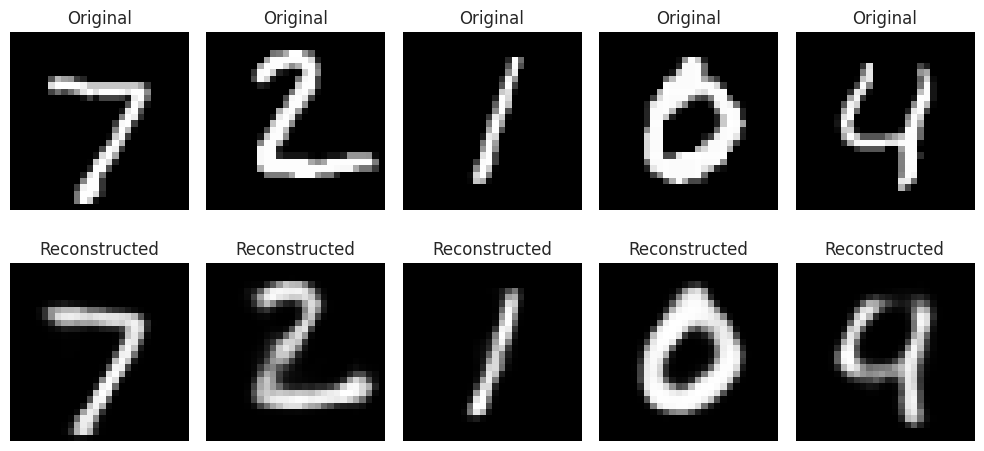

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# PART 2: Train and visualize for latent dimensions = 4 and 16 with Seaborn-enhanced T-SNE
def part2():
    for latent_dim in [4, 16]:
        model = VAE(latent_dim)
        if torch.cuda.is_available():
            model.cuda()

        optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, "max", factor=0.5, patience=5, threshold=0.001, cooldown=0, min_lr=0.0001, verbose=True
        )

        for epoch in range(1, 11):  # 10 epochs
            model.train()
            train_loss = 0
            for batch_idx, (data, _) in enumerate(trainloader):
                data = data.cuda()
                recon_batch, mu, std = model(data)
                loss, err, kld = loss_function(recon_batch, data, mu, std)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            scheduler.step(train_loss / len(trainloader.dataset))
            print(f"Latent Dim {latent_dim}, Epoch {epoch}, Train Loss: {train_loss / len(trainloader.dataset):.4f}")

        # Visualization: Reconstruction
        model.eval()
        data, _ = next(iter(testloader))
        data = data.cuda()
        with torch.no_grad():
            recon_batch, _, _ = model(data)
        plt.figure(figsize=(10, 5))
        for i in range(5):  # Visualize 5 pairs of original and reconstructed images
            plt.subplot(2, 5, i + 1)
            plt.imshow(data[i].view(28, 28).cpu().numpy(), cmap="gray")
            plt.axis('off')
            plt.title("Original")
            plt.subplot(2, 5, i + 6)
            plt.imshow(recon_batch[i].view(28, 28).cpu().numpy(), cmap="gray")
            plt.axis('off')
            plt.title("Reconstructed")
        plt.tight_layout()
        plt.show()

        # T-SNE visualization with Seaborn
        latent_vectors, labels = [], []
        with torch.no_grad():
            for data, label in testloader:
                data = data.cuda()
                _, mu, _ = model(data)
                latent_vectors.append(mu.cpu())
                labels.append(label)
        latent_vectors = torch.cat(latent_vectors)
        labels = torch.cat(labels)

        # Apply T-SNE
        tsne = TSNE(n_components=2, random_state=42)
        reduced_vectors = tsne.fit_transform(latent_vectors)

        # Create a DataFrame for Seaborn visualization
        tsne_df = pd.DataFrame({
            't-SNE Dimension 1': reduced_vectors[:, 0],
            't-SNE Dimension 2': reduced_vectors[:, 1],
            'Label': labels.numpy()
        })

        # Seaborn scatterplot
        plt.figure(figsize=(10, 8))
        sns.scatterplot(
            x="t-SNE Dimension 1", y="t-SNE Dimension 2",
            hue="Label",
            palette="tab10",
            data=tsne_df,
            legend="full",
            alpha=0.7
        )
        plt.title(f"T-SNE Visualization (Latent Dim = {latent_dim})")
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.legend(title="Classes")
        plt.tight_layout()
        plt.show()

part2()


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.44MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Latent Dim 2 - Epoch 1, Loss: 191.1072
Latent Dim 2 - Epoch 2, Loss: 169.2805
Latent Dim 2 - Epoch 3, Loss: 164.0144
Latent Dim 2 - Epoch 4, Loss: 161.1624
Latent Dim 2 - Epoch 5, Loss: 159.2078
Latent Dim 2 - Epoch 6, Loss: 157.7852
Latent Dim 2 - Epoch 7, Loss: 156.6166
Latent Dim 2 - Epoch 8, Loss: 155.6531
Latent Dim 2 - Epoch 9, Loss: 154.9370
Latent Dim 2 - Epoch 10, Loss: 154.2356


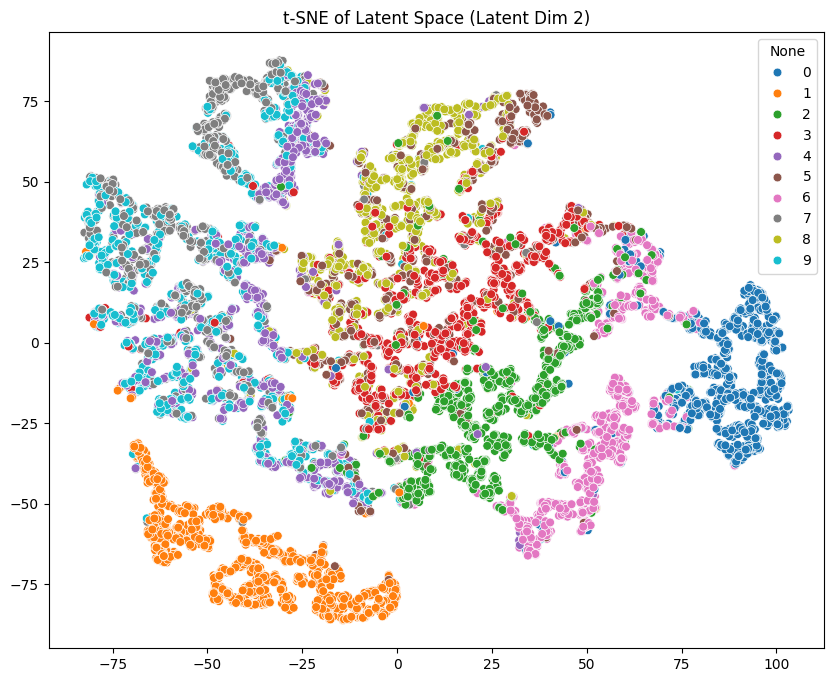

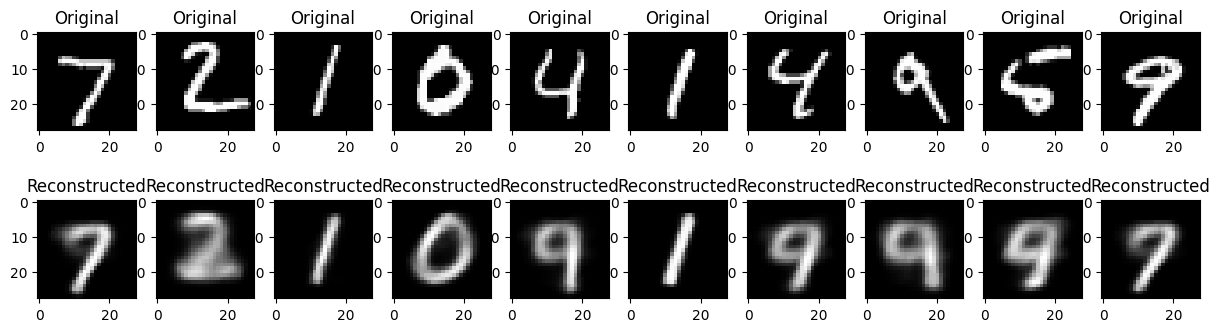

Latent Dim 4 - Epoch 1, Loss: 171.8606
Latent Dim 4 - Epoch 2, Loss: 145.9617
Latent Dim 4 - Epoch 3, Loss: 141.6923
Latent Dim 4 - Epoch 4, Loss: 139.1017
Latent Dim 4 - Epoch 5, Loss: 137.2747
Latent Dim 4 - Epoch 6, Loss: 135.8831
Latent Dim 4 - Epoch 7, Loss: 134.7913
Latent Dim 4 - Epoch 8, Loss: 133.9006
Latent Dim 4 - Epoch 9, Loss: 133.1158
Latent Dim 4 - Epoch 10, Loss: 132.4827


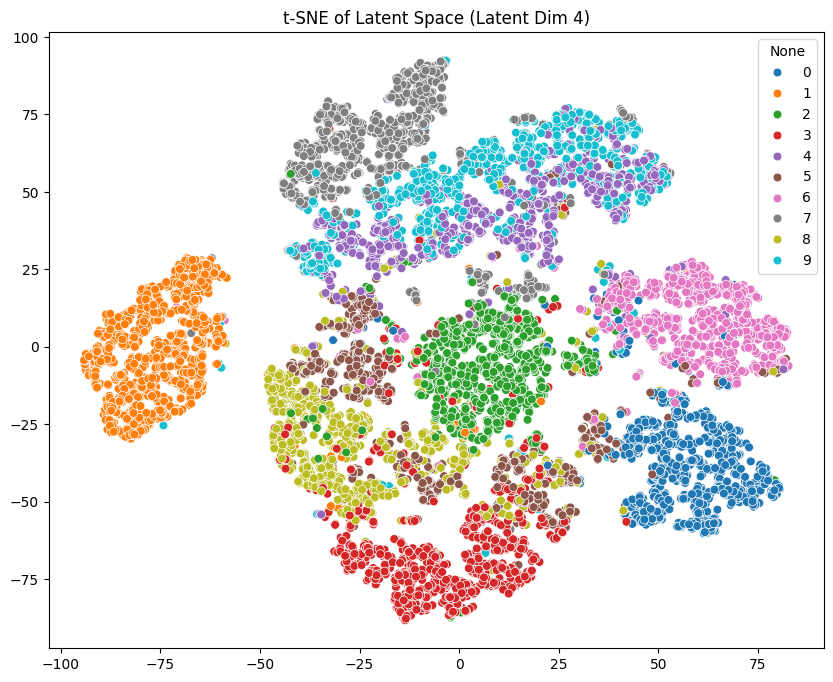

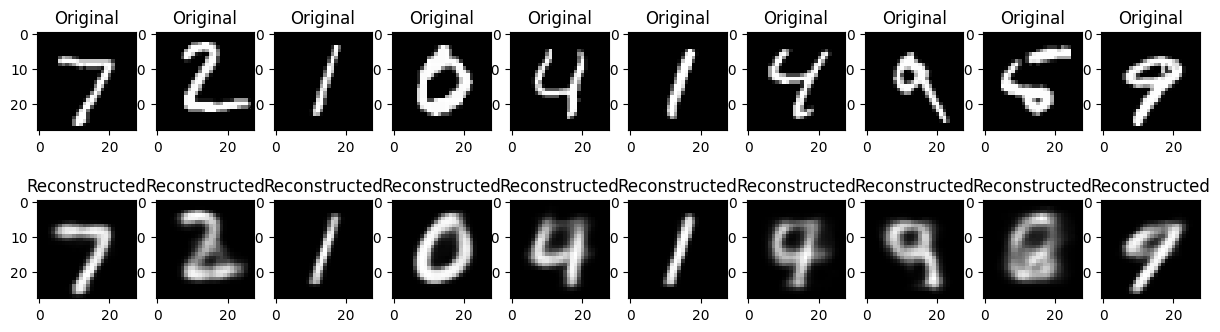

Latent Dim 16 - Epoch 1, Loss: 164.1285
Latent Dim 16 - Epoch 2, Loss: 121.3999
Latent Dim 16 - Epoch 3, Loss: 115.1912
Latent Dim 16 - Epoch 4, Loss: 112.3251
Latent Dim 16 - Epoch 5, Loss: 110.6736
Latent Dim 16 - Epoch 6, Loss: 109.4848
Latent Dim 16 - Epoch 7, Loss: 108.6313
Latent Dim 16 - Epoch 8, Loss: 107.9676
Latent Dim 16 - Epoch 9, Loss: 107.4659
Latent Dim 16 - Epoch 10, Loss: 106.9837


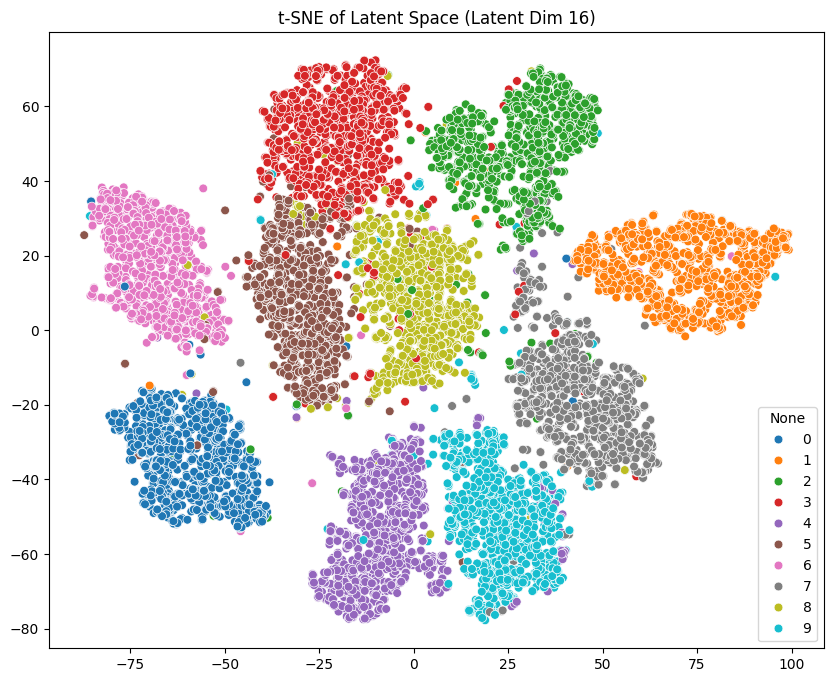

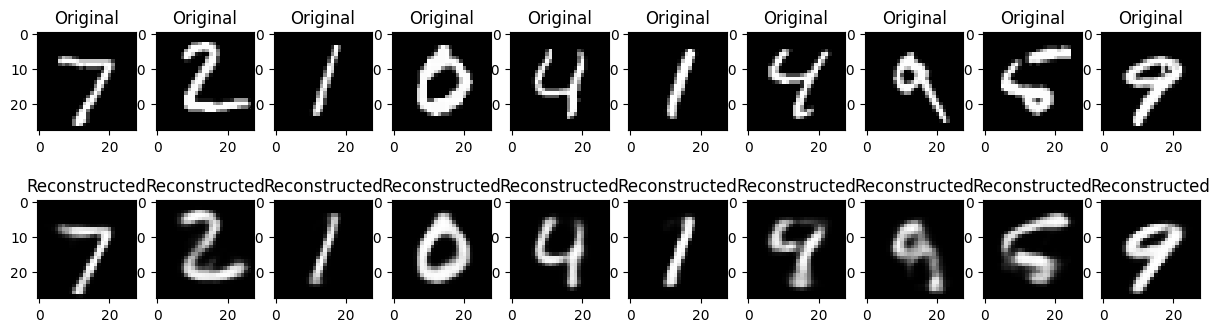

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Define VAE with variable latent dimensions
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 2 * latent_dim)  # mu and log_var
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = h[:, :self.latent_dim], h[:, self.latent_dim:]
        z = self.reparameterize(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x.view(-1, 1, 28, 28), mu, log_var

# Loss function
def loss_function(recon_x, x, mu, log_var):
    bce_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return bce_loss + kld, bce_loss, kld

# Data loaders
transform = transforms.ToTensor()
trainloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)
testloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=128, shuffle=False
)

# Function to train and evaluate the model for different latent dimensions
def train_and_visualize(latent_dim):
    model = VAE(latent_dim).cuda()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training loop
    for epoch in range(1, 11):
        model.train()
        train_loss = 0
        for data, _ in trainloader:
            data = data.cuda()
            optimizer.zero_grad()
            recon_batch, mu, log_var = model(data)
            loss, bce, kld = loss_function(recon_batch, data, mu, log_var)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f"Latent Dim {latent_dim} - Epoch {epoch}, Loss: {train_loss / len(trainloader.dataset):.4f}")

    # Visualize Latent Space with t-SNE
    latent_vectors, labels = [], []
    with torch.no_grad():
        for data, label in testloader:
            data = data.cuda()
            _, mu, _ = model(data)
            latent_vectors.append(mu.cpu())
            labels.append(label)
    latent_vectors = torch.cat(latent_vectors)
    labels = torch.cat(labels)

    # Apply t-SNE to reduce the latent space to 2D
    tsne = TSNE(n_components=2, random_state=42)
    latent_vectors_2d = tsne.fit_transform(latent_vectors)

    # Visualize using Seaborn
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=latent_vectors_2d[:, 0], y=latent_vectors_2d[:, 1], hue=labels, palette="tab10", s=40, marker='o', legend="full")
    plt.title(f"t-SNE of Latent Space (Latent Dim {latent_dim})")
    plt.show()

    # Visualize Original vs Reconstructed Images
    model.eval()
    data, _ = next(iter(testloader))
    data = data.cuda()
    with torch.no_grad():
        recon_batch, _, _ = model(data)
    fig, axes = plt.subplots(2, 10, figsize=(15, 4))
    for i in range(10):
        axes[0, i].imshow(data[i].cpu().squeeze(), cmap="gray")
        axes[0, i].set_title("Original")
        axes[1, i].imshow(recon_batch[i].cpu().squeeze(), cmap="gray")
        axes[1, i].set_title("Reconstructed")
    plt.show()

# Train and visualize for different latent dimensions
for latent_dim in [2, 4, 16]:
    train_and_visualize(latent_dim)


In [ ]:
# Restart the Colab runtime
import os
os.kill(os.getpid(), 9)
